# 1. Business Case Discovery

## 1.1 Contexto del Negocio y Antecedentes

Una importante compañía de envíos ha decidido modernizar su sistema de ruteo de correspondencia, paquetes y encomiendas. Actualmente, el proceso de clasificación se realiza de manera semi-automática y con intervención manual, lo que ocasiona demoras y errores en la entrega.
El negocio ha identificado que el reconocimiento automático de los dígitos que componen el código postal en los paquetes puede agilizar el proceso y reducir costos operativos, mejorando la satisfacción del cliente.

## 1.2 Objetivo del Proyecto

El propósito es desarrollar un sistema de reconocimiento de dígitos basado en un modelo de red neuronal convolucional que:
- Identifique correctamente los dígitos del código postal en imágenes de paquetes.
- Automatice el ruteo y la clasificación en función del código postal.

## 1.3 Métricas de Éxito
- Precisión (Accuracy): Porcentaje de dígitos reconocidos correctamente en cada imagen.
- Tiempo de Inferencia: Tiempo requerido para procesar cada imagen, clave para aplicaciones en tiempo real.
- Número de Parámetros: Comparación de la eficiencia del modelo, evaluando la complejidad y capacidad de generalización.

## 1.4 Desafíos y Consideraciones
- Calidad y Variabilidad de las Imágenes: Diferentes condiciones de iluminación, ángulos y ruido pueden dificultar la clasificación.
- Overfitting y Underfitting: Balancear la complejidad del modelo para que no se adapte excesivamente a las muestras de entrenamiento.

# 2. Data Processing

## 2.1 Dataset para Entrenamiento
Para este caso de estudio, utilizaremos el dataset MNIST (Modified National Institute of Standards and Technology), que contiene 70,000 imágenes en escala de grises (28x28 píxeles) de dígitos manuscritos (0-9). Este conjunto de datos es ampliamente utilizado para tareas de clasificación de imágenes y servirá como base para entrenar nuestro modelo de reconocimiento de dígitos en códigos postales.

In [1]:
import tensorflow as tf

(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"Formato de imágenes de entrenamiento: {x_train_full.shape}")
print(f"Formato de etiquetas de entrenamiento: {y_train_full.shape}")
print(f"Formato de imágenes de prueba: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Formato de imágenes de entrenamiento: (60000, 28, 28)
Formato de etiquetas de entrenamiento: (60000,)
Formato de imágenes de prueba: (10000, 28, 28)


## 2.2 Análisis Exploratorio y Visualización

### Visualizar múltiples muestras de dígitos en diferentes formatos

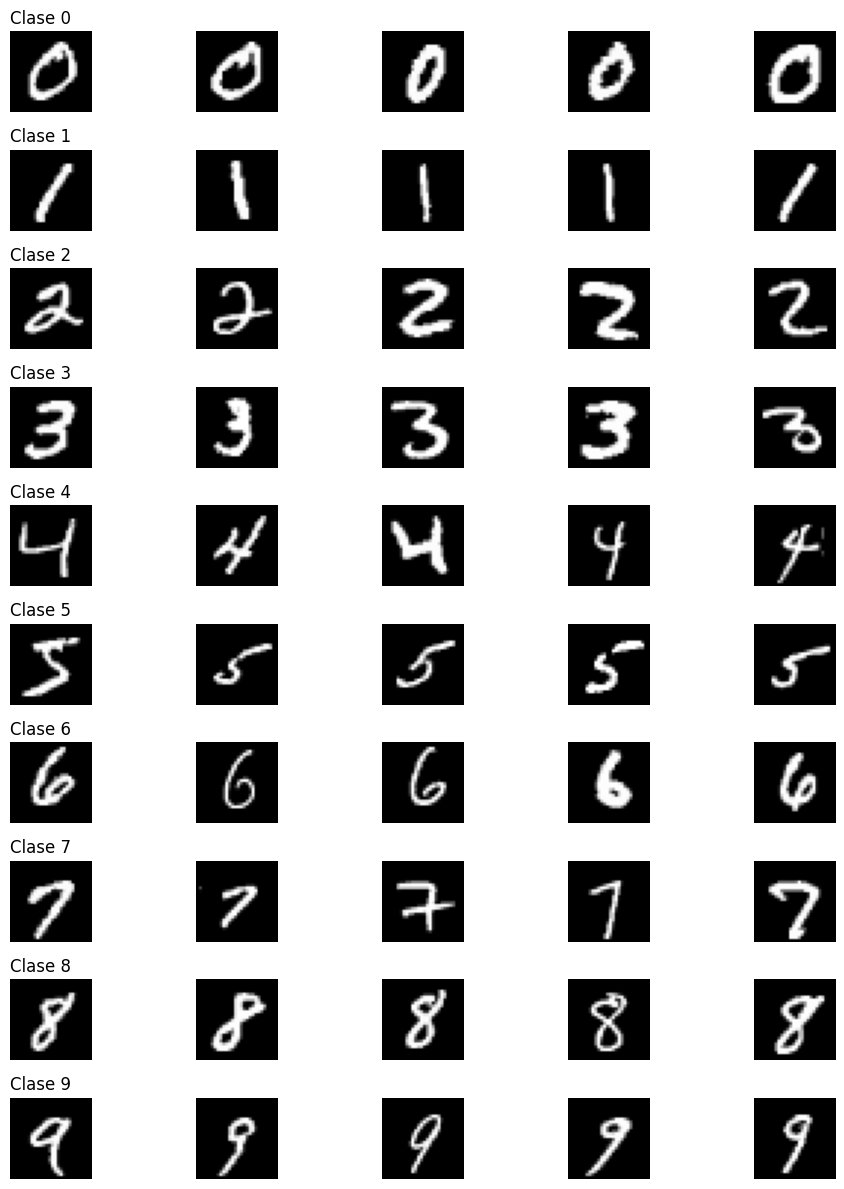

In [3]:
import matplotlib.pyplot as plt
import numpy as np

num_clases = 10
muestras_por_clase = 5

plt.figure(figsize=(10, 12))

for clase in range(num_clases):
    # Encontramos todos los índices correspondientes a la clase actual
    indices = np.where(y_train_full == clase)[0]
    
    for i in range(muestras_por_clase):
        # Calculamos la posición en la cuadrícula (10 filas x 5 columnas)
        plt.subplot(num_clases, muestras_por_clase, clase * muestras_por_clase + i + 1)
        plt.imshow(x_train_full[indices[i]], cmap='gray')
        plt.axis("off")
        
        # Ponemos título solo a la primera columna para identificar la fila
        if i == 0:
            plt.title(f"Clase {clase}", loc='left')

plt.tight_layout()
plt.show()

### Histogramas y Diagramas de Dispersión para el analisis de la distribución de las clases

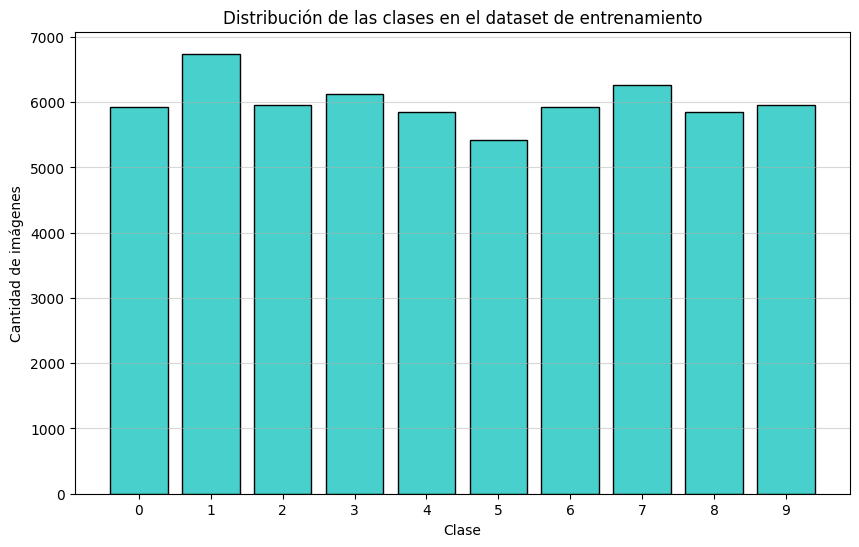

In [5]:
plt.figure(figsize=(10, 6))

# Usamos bins alineados a los números del 0 al 9 para crear el histograma
plt.hist(y_train_full, bins=np.arange(-0.5, 10.5, 1), rwidth=0.8, color='mediumturquoise', edgecolor='black')

plt.xticks(range(10))
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de las clases en el dataset de entrenamiento")
plt.grid(axis='y', alpha=0.5)

plt.show()

Al observar el histograma, se aprecia un ligero desbalance entre el dígito 1, siendo esta la clase mayoritaria, y el dígito 5, la clase minoritaria 

En este caso el desbalance es leve con una diferencia aproximada de un 20% entre la clase mayoritaria y minoritaria, por lo que el modelo debería ser capaz de generalizar sin graves problemas. 

En caso de que este desbalance afectase al rendimiento, aplicaríamos augmentation focalizado transformando (mediante rotaciones leves, zoom...)exclusivamente a las clases minoritarias como el 5, hasta igualar el volumen del resto. Otra alternativa sería aplicar oversampling duplicando las muestras de las clases minoritarias.

### Posibles anomalías o sesgos en la distribución de imágenes

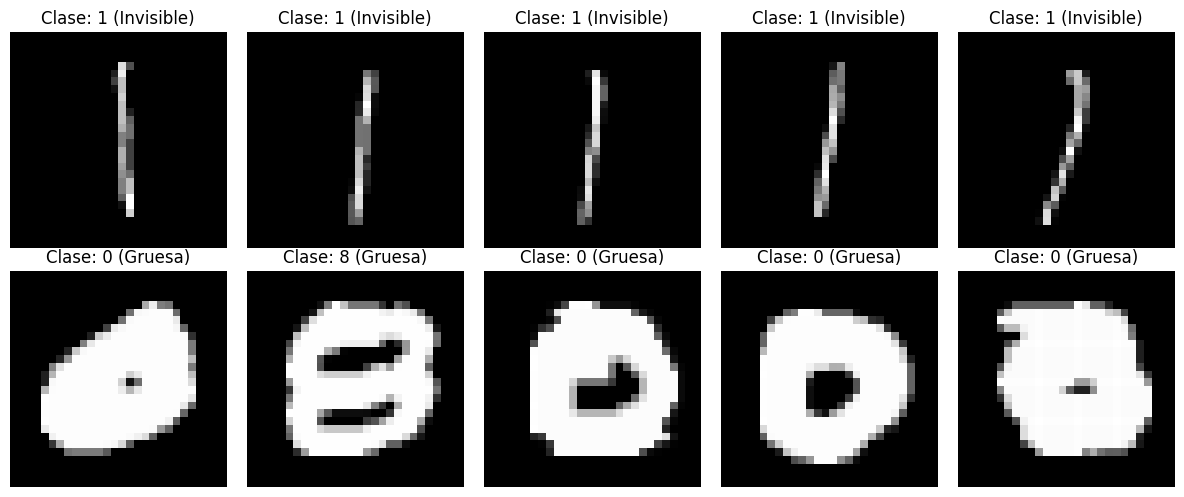

In [12]:
plt.figure(figsize=(12, 5))

# Calculamos la suma de píxeles de cada imagen
intensidad_total = np.sum(x_train_full, axis=(1, 2))

# Obtenemos los índices de las 5 imágenes con menor suma de píxeles y las 5 con mayor suma de píxeles
indices_baja_intensidad = np.argsort(intensidad_total)[:5]
indices_alta_intensidad = np.argsort(intensidad_total)[-5:]

# Imágenes casi invisibles o rotas
for i, idx in enumerate(indices_baja_intensidad):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[idx], cmap='gray')
    plt.title(f"Clase: {y_train_full[idx]} (Invisible)")
    plt.axis("off")

# Imágenes demasiado gruesas o manchadas
for i, idx in enumerate(indices_alta_intensidad):
    plt.subplot(2, 5, i + 6)
    plt.imshow(x_train_full[idx], cmap='gray')
    plt.title(f"Clase: {y_train_full[idx]} (Gruesa)")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 3. Model Planning

# 4. Model Building and Selection

# 5. Presentación de Resultados

# 6. Deployment

# Conclusión